In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [8]:
# Paths
RAW_CSV    = Path("../data/raw/tabular_data/angles_dataset.csv")
CLEAN_CSV  = Path("../data/processed/tabular_data/angles_dataset_clean.csv")

# Load
df = pd.read_csv(RAW_CSV)

print("✅ Dataset loaded.")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {list(df.columns)}")
display(df.head())

✅ Dataset loaded.
   Shape   : (27456, 30)
   Columns : ['video_id', 'frame_number', 'left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle', 'left_hip_angle', 'right_hip_angle', 'left_knee_angle', 'right_knee_angle', 'left_ankle_angle', 'right_ankle_angle', 'shoulder_z_diff', 'hip_z_diff', 'torso_rotation', 'left_elbow_angle_velocity', 'right_elbow_angle_velocity', 'left_shoulder_angle_velocity', 'right_shoulder_angle_velocity', 'left_hip_angle_velocity', 'right_hip_angle_velocity', 'left_knee_angle_velocity', 'right_knee_angle_velocity', 'left_ankle_angle_velocity', 'right_ankle_angle_velocity', 'shoulder_z_diff_velocity', 'hip_z_diff_velocity', 'torso_rotation_velocity', 'exercise_name', 'exercise_correctness']


,video_id,frame_number,left_elbow_angle,right_elbow_angle,left_shoulder_angle,right_shoulder_angle,left_hip_angle,right_hip_angle,left_knee_angle,right_knee_angle,...,right_hip_angle_velocity,left_knee_angle_velocity,right_knee_angle_velocity,left_ankle_angle_velocity,right_ankle_angle_velocity,shoulder_z_diff_velocity,hip_z_diff_velocity,torso_rotation_velocity,exercise_name,exercise_correctness
0,0,0,165.92,176.17,160.69,173.34,168.20,173.08,176.95,171.07,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,pullup,correct
1,0,1,167.38,178.32,160.27,171.76,168.42,173.78,177.05,175.20,...,21.0,3.0,123.9,87.6,376.2,0.29,0.12,0.16,pullup,correct
2,0,2,166.59,179.51,158.92,169.74,168.47,174.47,177.16,176.46,...,20.7,3.3,37.8,234.6,13.2,2.01,1.17,0.84,pullup,correct
3,0,3,165.42,177.20,158.65,168.31,167.29,174.86,176.81,177.64,...,11.7,10.5,35.4,127.8,60.9,2.54,0.03,2.51,pullup,correct
4,0,4,166.39,173.75,158.61,165.83,167.67,174.92,176.35,179.51,...,1.8,13.8,56.1,483.9,106.5,0.39,0.26,0.13,pullup,correct


In [9]:
print("=" * 60)
print("📋 BASIC INSPECTION")
print("=" * 60)

# 1. Data types
print("\n📌 Column Data Types:")
display(df.dtypes)

# 2. Basic statistics
print("\n📌 Basic Statistics:")
display(df.describe())

# 3. Null values
print("\n📌 Null Values:")
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print("✅ No null values found.")
else:
    print("⚠️  Null values detected:")
    display(null_counts[null_counts > 0])

# 4. Duplicate rows
dupe_count = df.duplicated().sum()
if dupe_count == 0:
    print("\n✅ No duplicate rows found.")
else:
    print(f"\n⚠️  {dupe_count} duplicate rows found.")

# 5. Class distributions
print("\n📌 Exercise Distribution:")
display(df["exercise_name"].value_counts())

print("\n📌 Correctness Distribution:")
display(df["exercise_correctness"].value_counts())

print("\n📌 Exercise × Correctness Breakdown:")
display(df.groupby(["exercise_name", "exercise_correctness"]).size().unstack(fill_value=0))

📋 BASIC INSPECTION

📌 Column Data Types:


video_id                           int64
frame_number                       int64
left_elbow_angle                 float64
right_elbow_angle                float64
left_shoulder_angle              float64
right_shoulder_angle             float64
left_hip_angle                   float64
right_hip_angle                  float64
left_knee_angle                  float64
right_knee_angle                 float64
left_ankle_angle                 float64
right_ankle_angle                float64
shoulder_z_diff                  float64
hip_z_diff                       float64
torso_rotation                   float64
left_elbow_angle_velocity        float64
right_elbow_angle_velocity       float64
left_shoulder_angle_velocity     float64
right_shoulder_angle_velocity    float64
left_hip_angle_velocity          float64
right_hip_angle_velocity         float64
left_knee_angle_velocity         float64
right_knee_angle_velocity        float64
left_ankle_angle_velocity        float64
right_ankle_angl


📌 Basic Statistics:


,video_id,frame_number,left_elbow_angle,right_elbow_angle,left_shoulder_angle,right_shoulder_angle,left_hip_angle,right_hip_angle,left_knee_angle,right_knee_angle,...,right_shoulder_angle_velocity,left_hip_angle_velocity,right_hip_angle_velocity,left_knee_angle_velocity,right_knee_angle_velocity,left_ankle_angle_velocity,right_ankle_angle_velocity,shoulder_z_diff_velocity,hip_z_diff_velocity,torso_rotation_velocity
count,27456.000000,27456.000000,27456.000000,27456.000000,27456.000000,27456.000000,27456.000000,27456.000000,27456.000000,27456.000000,...,27456.000000,27456.000000,27456.000000,27456.000000,27456.000000,27456.000000,27456.000000,27456.000000,27456.000000,27456.000000
mean,121.581876,89.662551,119.361214,117.251677,66.316198,68.040743,127.587192,129.427377,138.636608,139.006342,...,74.616375,55.953278,43.549671,58.064881,53.021223,98.843727,91.839765,0.567384,0.190502,0.438471
std,55.885045,79.704245,44.541901,46.304342,49.167699,47.408438,51.408627,50.663986,41.792427,43.374345,...,118.603757,194.715557,140.872406,130.338556,137.139987,150.819179,135.912362,0.660931,0.294977,0.488879
min,0.000000,0.000000,0.020000,0.010000,0.000000,0.000000,6.360000,2.240000,8.790000,0.150000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,98.000000,28.000000,88.950000,81.515000,18.100000,24.060000,61.462500,63.587500,92.847500,91.717500,...,16.800000,8.700000,9.000000,11.700000,10.800000,20.700000,20.700000,0.130000,0.020000,0.100000
50%,123.000000,58.000000,130.110000,128.050000,62.875000,62.000000,154.690000,155.020000,160.100000,161.760000,...,43.500000,23.100000,22.820000,28.800000,27.300000,52.200000,50.100000,0.340000,0.080000,0.270000
75%,147.000000,143.000000,157.020000,156.830000,97.350000,102.482500,168.040000,168.082500,172.090000,172.960000,...,92.100000,51.300000,48.900000,64.200000,60.900000,118.200000,109.800000,0.770000,0.240000,0.610000
max,243.000000,325.000000,180.000000,180.000000,179.990000,179.920000,180.000000,180.000000,180.000000,180.000000,...,3530.100000,3650.100000,4770.900000,4291.800000,4638.300000,3897.900000,4732.500000,7.690000,6.300000,5.910000



📌 Null Values:
✅ No null values found.

✅ No duplicate rows found.

📌 Exercise Distribution:


exercise_name
russian_twist    7275
pushup           7039
squat            6834
pullup           6308
Name: count, dtype: int64


📌 Correctness Distribution:


exercise_correctness
incorrect    13825
correct      13631
Name: count, dtype: int64


📌 Exercise × Correctness Breakdown:


exercise_correctness,correct,incorrect
exercise_name,,
pullup,3007,3301
pushup,3628,3411
russian_twist,3643,3632
squat,3353,3481


In [10]:
print("=" * 60)
print("🧹 ANGLE RANGE VALIDATION & CLEANING")
print("=" * 60)

# Separate angle and velocity columns
angle_cols    = [col for col in df.columns if "angle" in col and "velocity" not in col]
velocity_cols = [col for col in df.columns if "velocity" in col]

print(f"\n📌 Angle columns    ({len(angle_cols)})  : {angle_cols}")
print(f"📌 Velocity columns ({len(velocity_cols)}): {velocity_cols}")

# --- 1. Check angles outside [0, 180] ---
print("\n📌 Frames with at least one angle outside [0°, 180°]:")
invalid_angle_mask = df[angle_cols].apply(lambda col: (col < 0) | (col > 180)).any(axis=1)
invalid_angle_count = invalid_angle_mask.sum()

if invalid_angle_count == 0:
    print("✅ All angles are within [0°, 180°].")
else:
    print(f"⚠️  {invalid_angle_count} frames have out-of-range angles — will be removed.")
    display(df[invalid_angle_mask][angle_cols].describe())

# --- 2. Check torso rotation features (no fixed range, just sanity check) ---
print("\n📌 Torso rotation features range:")
torso_cols = ["shoulder_z_diff", "hip_z_diff", "torso_rotation"]
display(df[torso_cols].describe())

# --- 3. Check for unrealistic velocities (e.g. > 3000 °/s is almost certainly noise) ---
# 3000 °/s is ~16 full joint rotations per second — physically impossible
# for human movement. Frames exceeding this are MediaPipe tracking glitches.
# All training videos run at 30 fps; max realistic velocity ~600 °/s (sprinting).
VELOCITY_THRESHOLD = 3000  # degrees per second
print(f"\n📌 Frames with any velocity > {VELOCITY_THRESHOLD}°/s (likely noise):")
invalid_velocity_mask = df[velocity_cols].apply(lambda col: col > VELOCITY_THRESHOLD).any(axis=1)
invalid_velocity_count = invalid_velocity_mask.sum()

if invalid_velocity_count == 0:
    print(f"✅ No unrealistic velocities found.")
else:
    print(f"⚠️  {invalid_velocity_count} frames have unrealistic velocities — will be removed.")

# --- 4. Remove all invalid frames ---
invalid_mask = invalid_angle_mask | invalid_velocity_mask
df_clean = df[~invalid_mask].reset_index(drop=True)

print(f"\n🗑️  Removed : {invalid_mask.sum()} invalid frames")
print(f"✅ Remaining: {len(df_clean)} frames")

# --- 5. Drop duplicate rows ---
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
after = len(df_clean)
print(f"\n🗑️  Duplicate rows removed: {before - after}")
print(f"✅ Final shape: {df_clean.shape}")

🧹 ANGLE RANGE VALIDATION & CLEANING

📌 Angle columns    (10)  : ['left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle', 'left_hip_angle', 'right_hip_angle', 'left_knee_angle', 'right_knee_angle', 'left_ankle_angle', 'right_ankle_angle']
📌 Velocity columns (13): ['left_elbow_angle_velocity', 'right_elbow_angle_velocity', 'left_shoulder_angle_velocity', 'right_shoulder_angle_velocity', 'left_hip_angle_velocity', 'right_hip_angle_velocity', 'left_knee_angle_velocity', 'right_knee_angle_velocity', 'left_ankle_angle_velocity', 'right_ankle_angle_velocity', 'shoulder_z_diff_velocity', 'hip_z_diff_velocity', 'torso_rotation_velocity']

📌 Frames with at least one angle outside [0°, 180°]:
✅ All angles are within [0°, 180°].

📌 Torso rotation features range:


,shoulder_z_diff,hip_z_diff,torso_rotation
count,27456.000000,27456.000000,27456.000000
mean,0.050903,0.037618,0.013285
std,0.291016,0.189647,0.119931
min,-0.612300,-0.390800,-0.320800
25%,-0.063900,-0.049300,-0.052000
50%,0.025700,0.017500,0.017600
75%,0.259900,0.203525,0.093400
max,0.766900,0.405000,0.468300



📌 Frames with any velocity > 3000°/s (likely noise):
⚠️  405 frames have unrealistic velocities — will be removed.

🗑️  Removed : 405 invalid frames
✅ Remaining: 27051 frames

🗑️  Duplicate rows removed: 0
✅ Final shape: (27051, 30)


📊 VISUALIZING CLEANED DISTRIBUTIONS


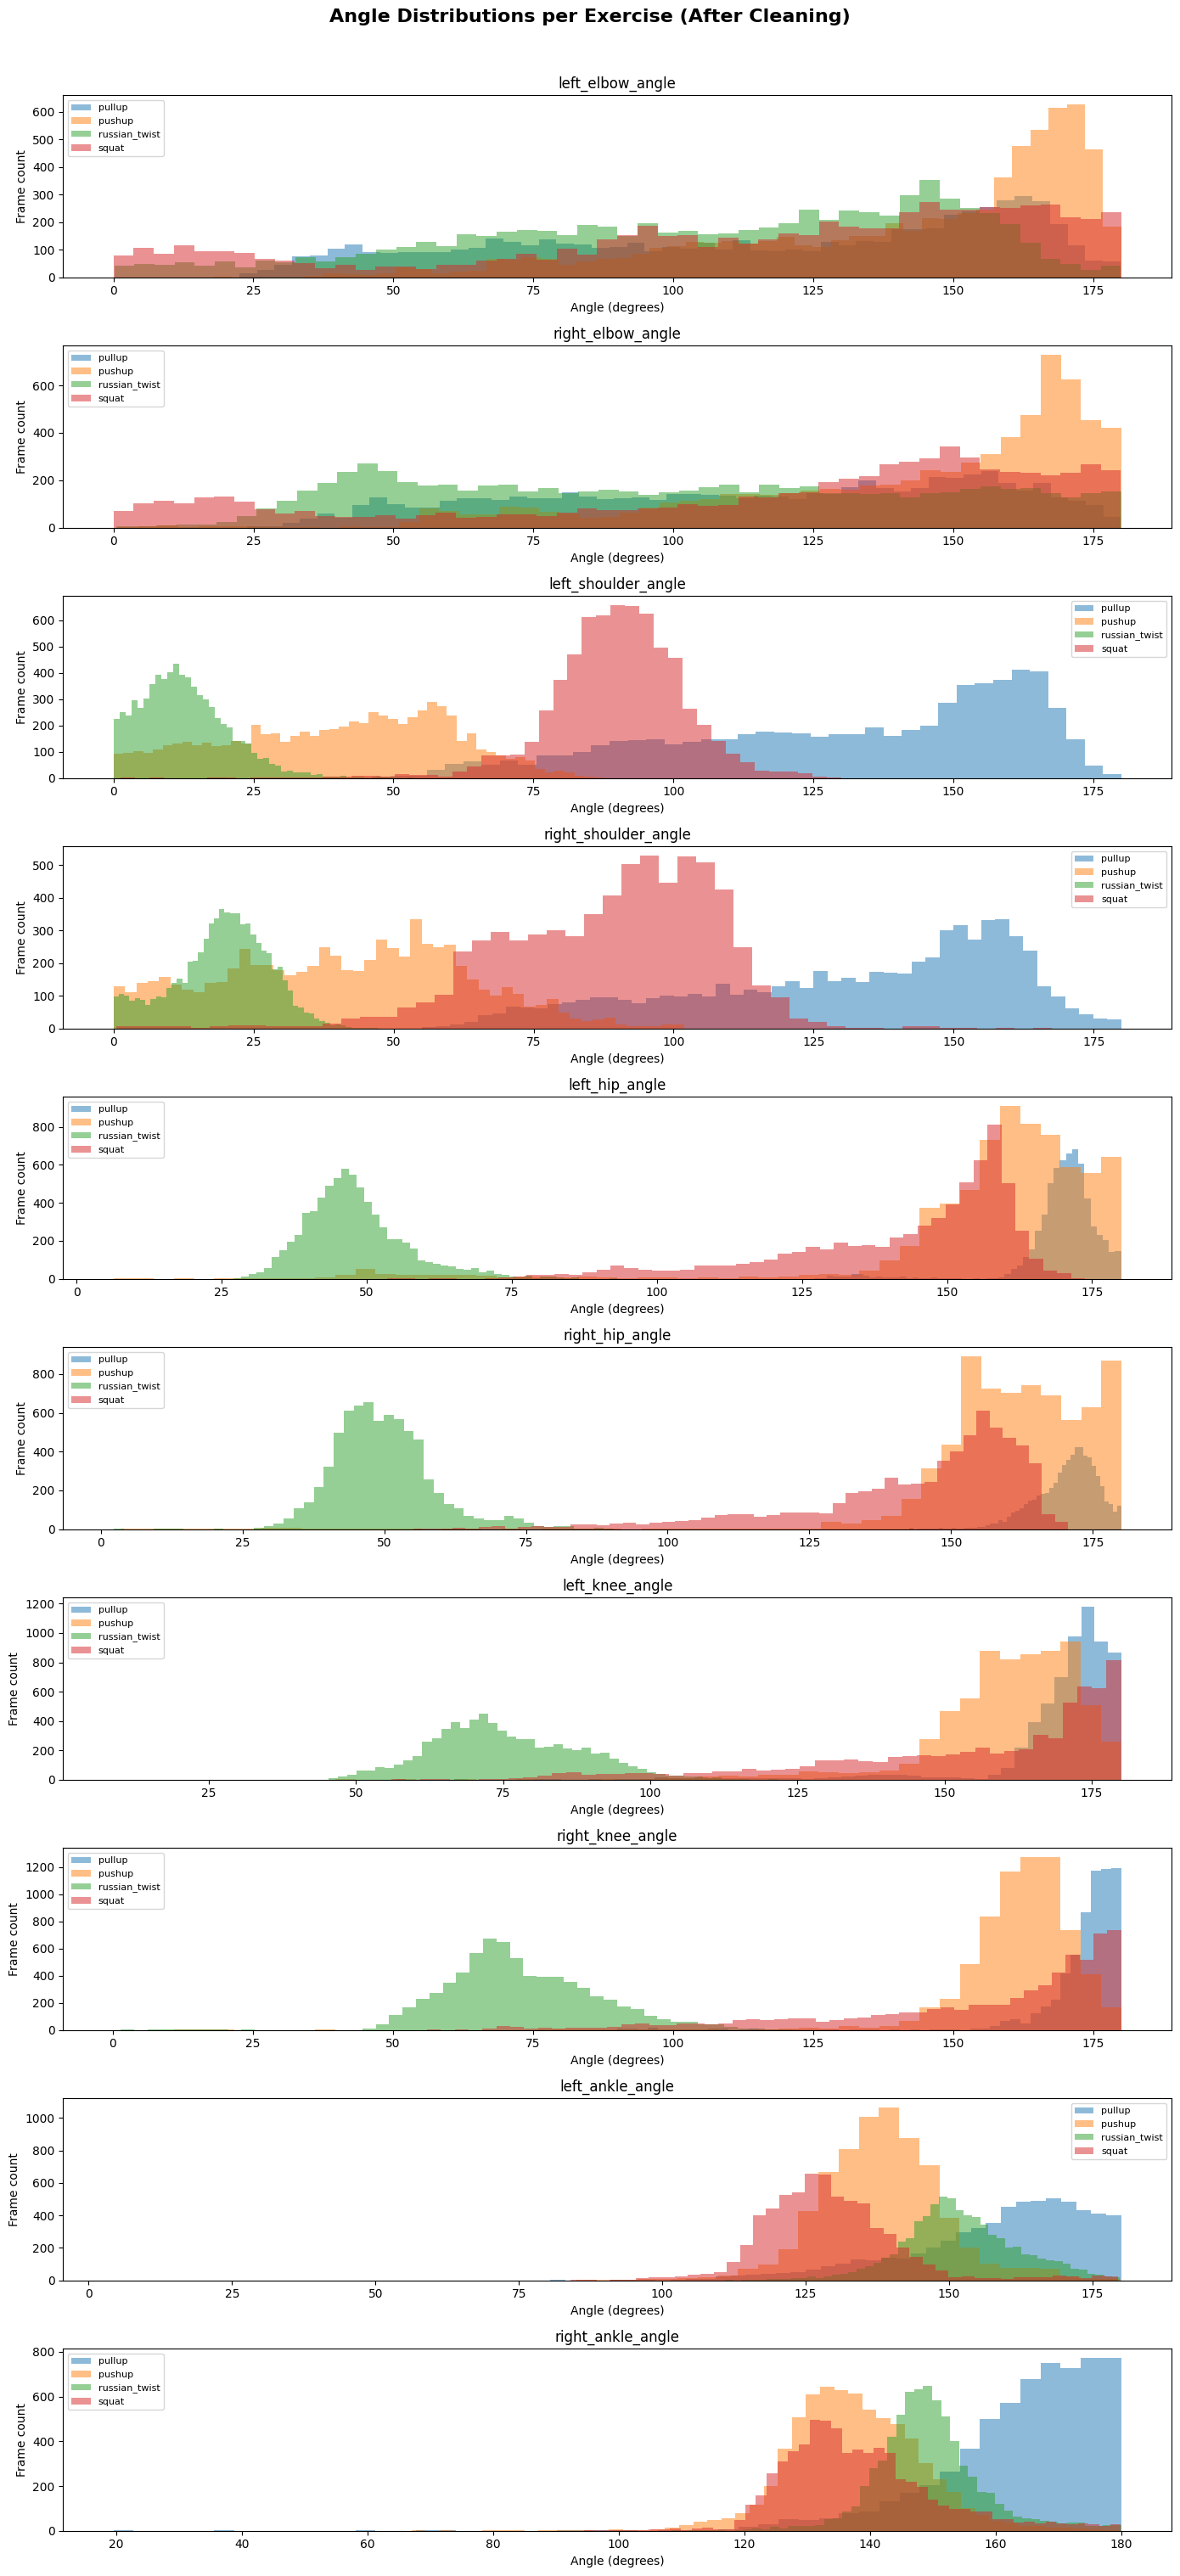

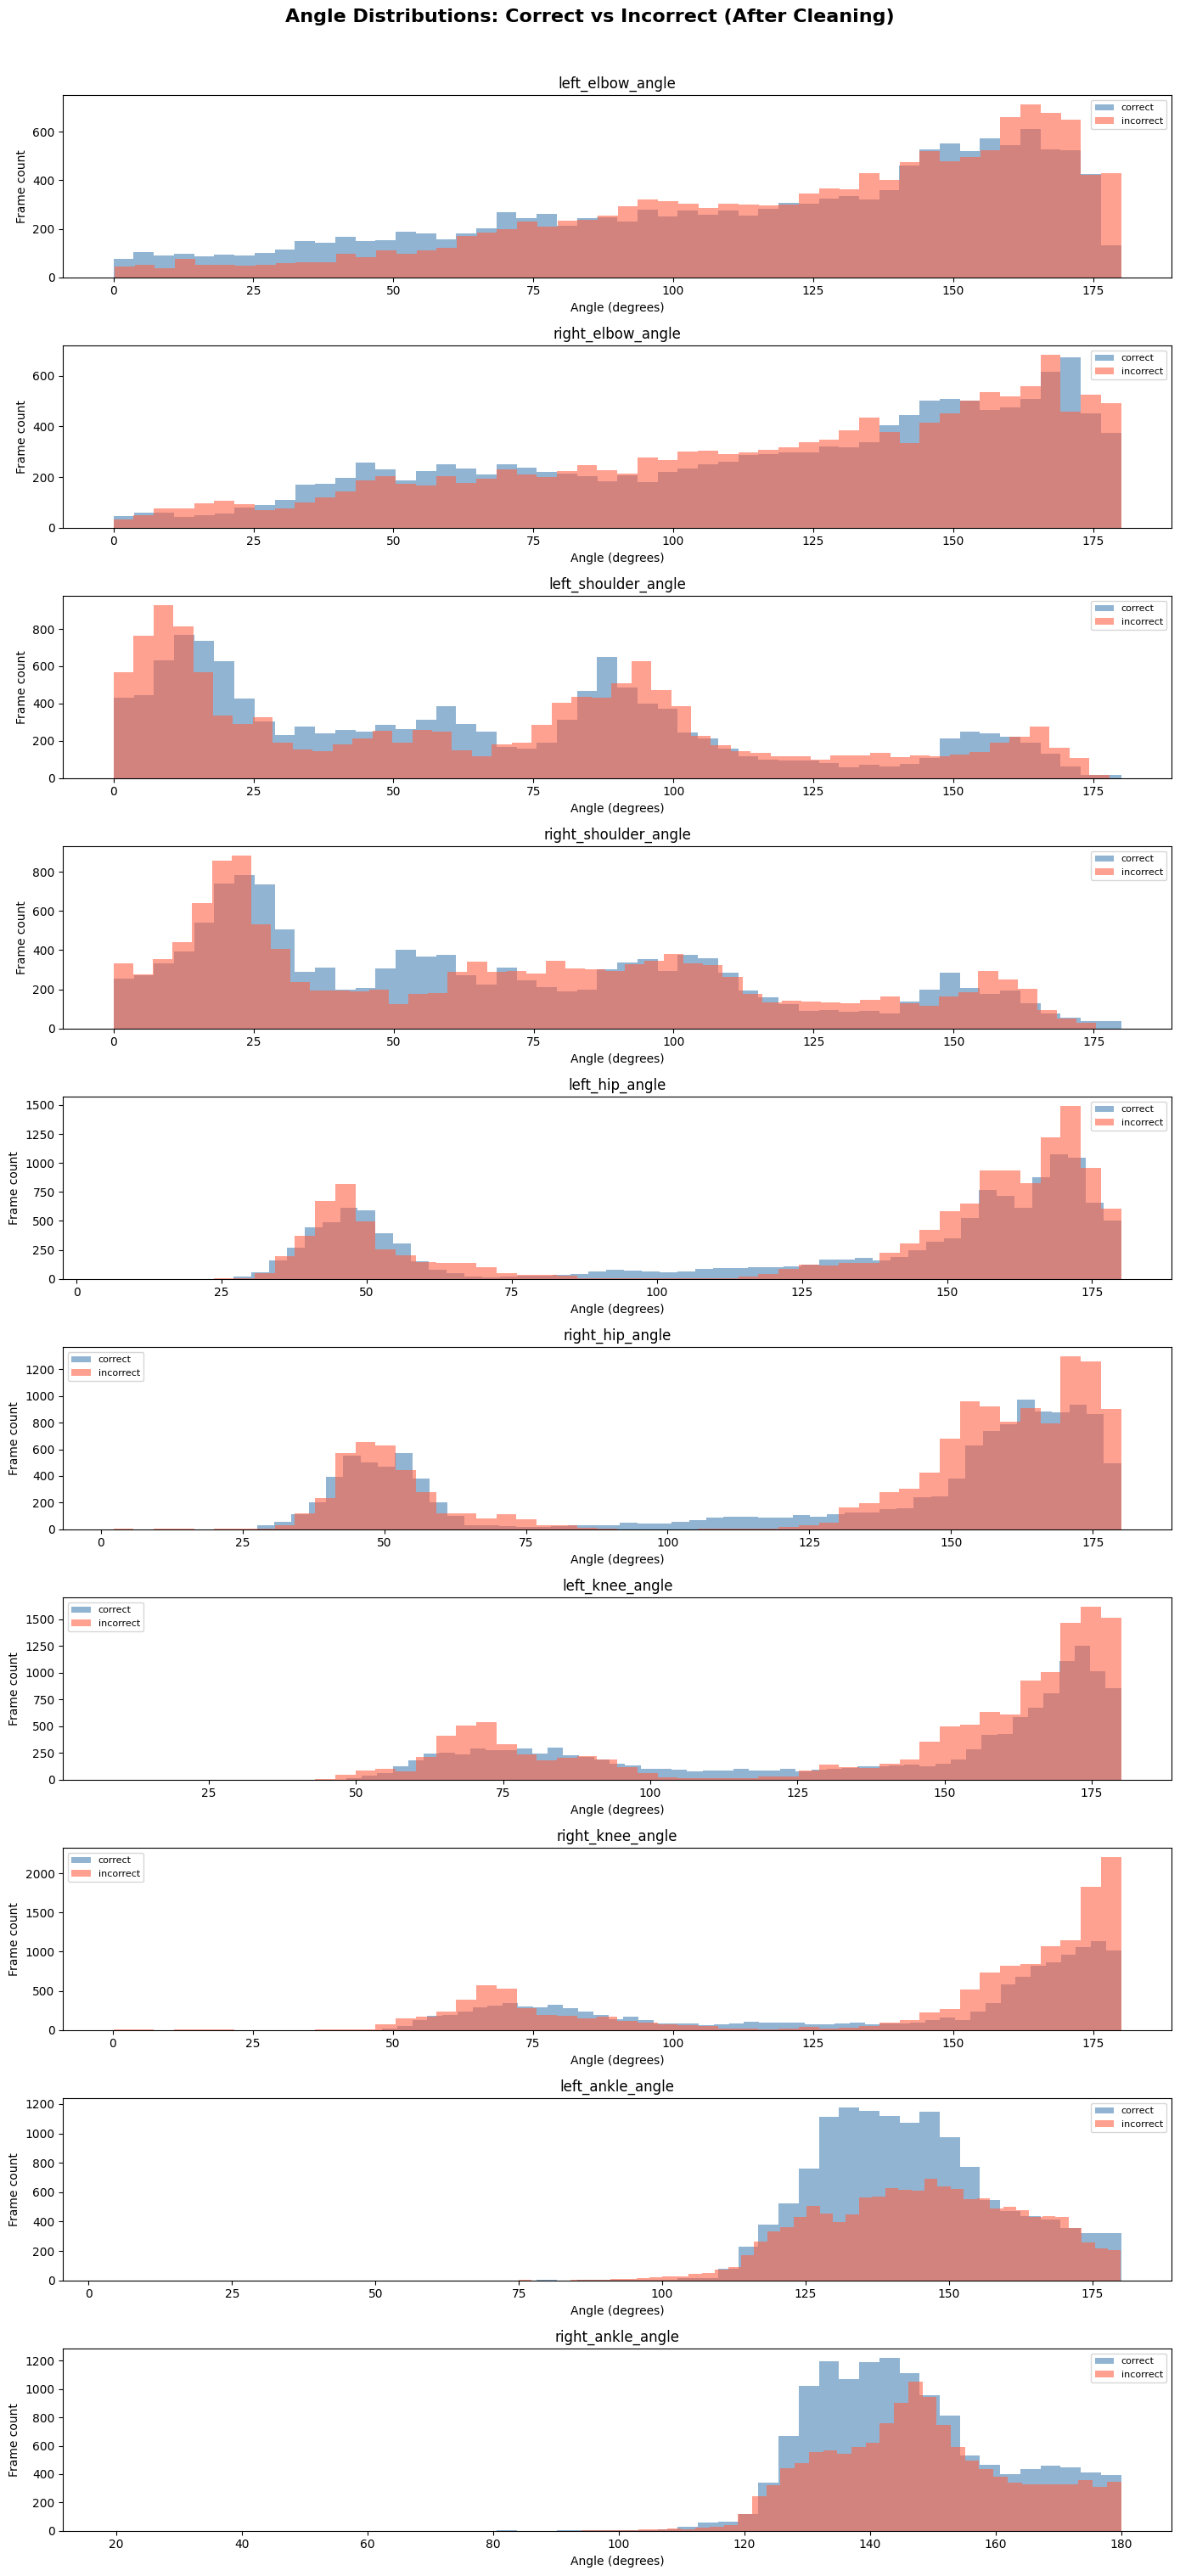

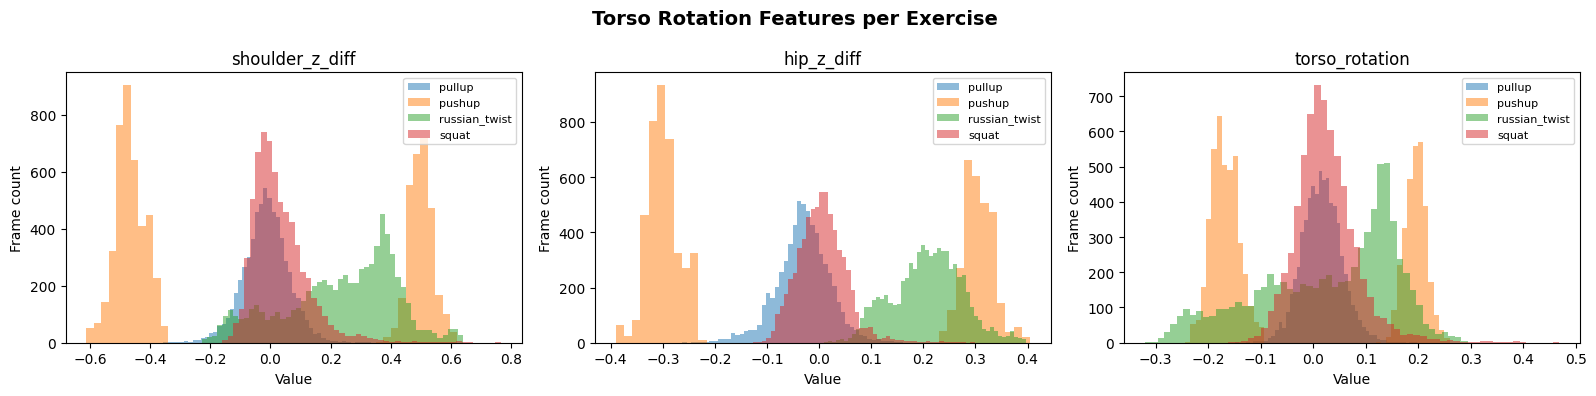

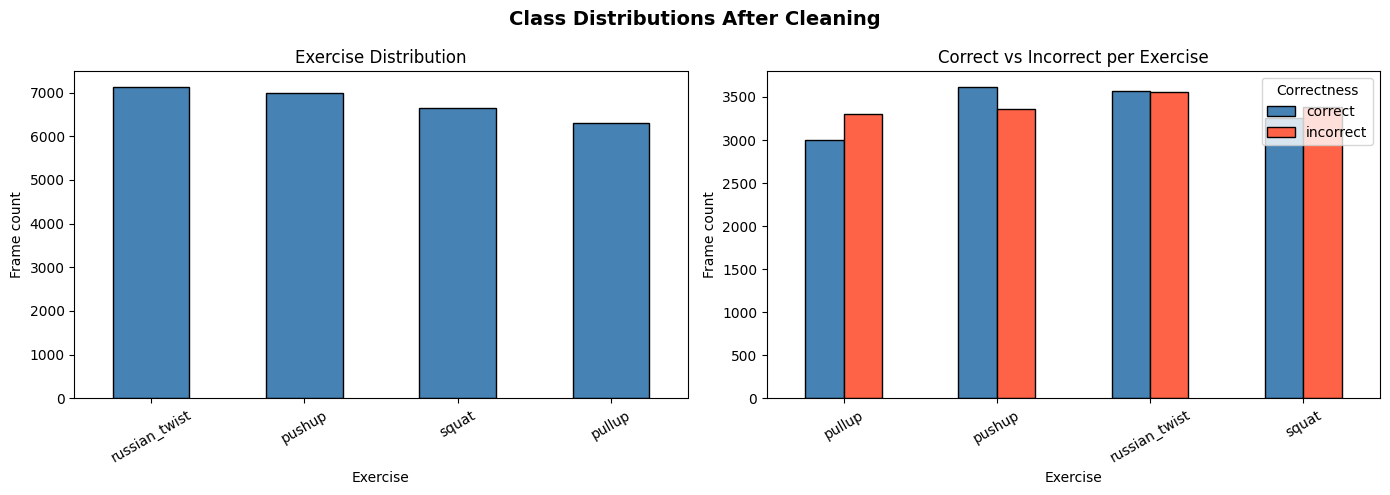

In [11]:
print("=" * 60)
print("📊 VISUALIZING CLEANED DISTRIBUTIONS")
print("=" * 60)

# --- 1. Angle distributions per exercise ---
fig, axes = plt.subplots(len(angle_cols), 1, figsize=(14, len(angle_cols) * 3))
fig.suptitle("Angle Distributions per Exercise (After Cleaning)", fontsize=16, fontweight="bold", y=1.01)

for ax, col in zip(axes, angle_cols):
    for exercise in df_clean["exercise_name"].unique():
        subset = df_clean[df_clean["exercise_name"] == exercise][col]
        ax.hist(subset, bins=50, alpha=0.5, label=exercise)
    ax.set_title(col)
    ax.set_xlabel("Angle (degrees)")
    ax.set_ylabel("Frame count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- 2. Correct vs Incorrect angle distributions ---
fig, axes = plt.subplots(len(angle_cols), 1, figsize=(14, len(angle_cols) * 3))
fig.suptitle("Angle Distributions: Correct vs Incorrect (After Cleaning)", fontsize=16, fontweight="bold", y=1.01)

for ax, col in zip(axes, angle_cols):
    for correctness, color in zip(["correct", "incorrect"], ["steelblue", "tomato"]):
        subset = df_clean[df_clean["exercise_correctness"] == correctness][col]
        ax.hist(subset, bins=50, alpha=0.6, label=correctness, color=color)
    ax.set_title(col)
    ax.set_xlabel("Angle (degrees)")
    ax.set_ylabel("Frame count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- 3. Torso rotation distribution per exercise ---
fig, axes = plt.subplots(1, len(torso_cols), figsize=(16, 4))
fig.suptitle("Torso Rotation Features per Exercise", fontsize=14, fontweight="bold")

for ax, col in zip(axes, torso_cols):
    for exercise in df_clean["exercise_name"].unique():
        subset = df_clean[df_clean["exercise_name"] == exercise][col]
        ax.hist(subset, bins=50, alpha=0.5, label=exercise)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frame count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- 4. Class distribution after cleaning ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Class Distributions After Cleaning", fontsize=14, fontweight="bold")

df_clean["exercise_name"].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="black"
)
axes[0].set_title("Exercise Distribution")
axes[0].set_xlabel("Exercise")
axes[0].set_ylabel("Frame count")
axes[0].tick_params(axis="x", rotation=30)

df_clean.groupby(["exercise_name", "exercise_correctness"]).size().unstack().plot(
    kind="bar", ax=axes[1], color=["steelblue", "tomato"], edgecolor="black"
)
axes[1].set_title("Correct vs Incorrect per Exercise")
axes[1].set_xlabel("Exercise")
axes[1].set_ylabel("Frame count")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Correctness")

plt.tight_layout()
plt.show()

In [12]:
print("=" * 60)
print("🔤 ENCODING LABELS")
print("=" * 60)

# --- 1. Encode exercise_name ---
exercise_mapping = {name: idx for idx, name in enumerate(sorted(df_clean["exercise_name"].unique()))}
correctness_mapping = {"correct": 1, "incorrect": 0}

print(f"\n📌 Exercise mapping    : {exercise_mapping}")
print(f"📌 Correctness mapping : {correctness_mapping}")

df_clean["exercise_name_encoded"]        = df_clean["exercise_name"].map(exercise_mapping)
df_clean["exercise_correctness_encoded"] = df_clean["exercise_correctness"].map(correctness_mapping)

# --- 2. Verify encoding ---
print("\n📌 Encoding verification:")
display(df_clean[["exercise_name", "exercise_name_encoded",
                   "exercise_correctness", "exercise_correctness_encoded"]].drop_duplicates().sort_values("exercise_name_encoded"))

# --- 3. Verify no nulls were introduced by encoding ---
encoding_nulls = df_clean[["exercise_name_encoded", "exercise_correctness_encoded"]].isnull().sum()
if encoding_nulls.sum() == 0:
    print("\n✅ Encoding successful, no nulls introduced.")
else:
    print("\n⚠️  Nulls introduced during encoding:")
    display(encoding_nulls[encoding_nulls > 0])

# --- 4. Verify all columns are now numerical (except original label columns) ---
non_numeric_cols = df_clean.drop(columns=["exercise_name", "exercise_correctness"]).select_dtypes(exclude=[np.number]).columns.tolist()
if not non_numeric_cols:
    print("✅ All columns (except original labels) are numerical.")
else:
    print(f"⚠️  Non-numerical columns detected: {non_numeric_cols}")

# --- 5. Final column overview ---
print(f"\n📌 Final columns ({len(df_clean.columns)}):")
display(df_clean.dtypes)

# --- 6. Save ---
df_clean.to_csv(CLEAN_CSV, index=False)
print(f"\n✅ Cleaned dataset saved to: {CLEAN_CSV}")
print(f"   Shape: {df_clean.shape}")

🔤 ENCODING LABELS

📌 Exercise mapping    : {'pullup': 0, 'pushup': 1, 'russian_twist': 2, 'squat': 3}
📌 Correctness mapping : {'correct': 1, 'incorrect': 0}

📌 Encoding verification:


,exercise_name,exercise_name_encoded,exercise_correctness,exercise_correctness_encoded
0,pullup,0,correct,1
3006,pullup,0,incorrect,0
6307,pushup,1,correct,1
9924,pushup,1,incorrect,0
13285,russian_twist,2,correct,1
16856,russian_twist,2,incorrect,0
20414,squat,3,correct,1
23665,squat,3,incorrect,0



✅ Encoding successful, no nulls introduced.
✅ All columns (except original labels) are numerical.

📌 Final columns (32):


video_id                           int64
frame_number                       int64
left_elbow_angle                 float64
right_elbow_angle                float64
left_shoulder_angle              float64
right_shoulder_angle             float64
left_hip_angle                   float64
right_hip_angle                  float64
left_knee_angle                  float64
right_knee_angle                 float64
left_ankle_angle                 float64
right_ankle_angle                float64
shoulder_z_diff                  float64
hip_z_diff                       float64
torso_rotation                   float64
left_elbow_angle_velocity        float64
right_elbow_angle_velocity       float64
left_shoulder_angle_velocity     float64
right_shoulder_angle_velocity    float64
left_hip_angle_velocity          float64
right_hip_angle_velocity         float64
left_knee_angle_velocity         float64
right_knee_angle_velocity        float64
left_ankle_angle_velocity        float64
right_ankle_angl


✅ Cleaned dataset saved to: ..\data\processed\tabular_data\angles_dataset_clean.csv
   Shape: (27051, 32)
